# 2026 实验7 调用Resnet模型参数搭建CNN分类网络

**任务：**  
**1. 使用Resnet18中的(conv1)、(bn1)、(relu)、(maxpool)层+(layer1)块+(layer2)块中的(conv1)、(bn1)、(relu)+两个自己的全连接层，组成分类网络，成功训练/测试**  
**2. 对比与3层卷积CNN网络的分类性能差异。**  
**3. 将数据读取部分，修改为使用Datasets和Dataloader。**

**解决思路：**  
**1. 参照ResNet18的结构，进行迁移学习补全网络结构即可**  
**2. 自己手写一个CNN网络，将手写CNN与迁移学习网络的表现进行对比**  
**3. 手写Datasets来加载本地数据集，并且使用Dataloader来实现mini-batch操作，特别的，我们直接将任务3的结果替换原文件的数据集加载方式**

## 读取数据

**下述多行注释部分为原文件中的数据集加载方式，我们直接将任务3的结果替换原文件中的写法**

In [4]:
"""
import os
from skimage.io import imread  #用来读取图片，支持多种类型：jpg/png/tif/gif等都可以
import numpy as np
from skimage.transform import resize  #将样本图像压缩/拉伸成正方形时会用到
import torch
from torch import nn
import matplotlib.pyplot as plt

def read_UC(folder_path):  # 这里补上参数名 folder_path
    # 读取文件夹内所有子文件夹的名称，注意os.path.isdir读取的是文件夹名而不是文件名
    subfolders = [name for name in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, name))]

    # 初始化变量
    X = []
    Y = []

    # 遍历每个子文件夹
    for index, subfolder in enumerate(subfolders):  #enumerate可用于同时遍历下标index和元素element
        # 获取子文件夹的路径和类别编号
        subfolder_path = os.path.join(folder_path, subfolder)
        label = index  #不妨将遍历下标作为这个文件夹中图片样本的标签，也就是说此处标签是阿拉伯数字
        
        # 遍历子文件夹内的所有tif图像
        for filename in os.listdir(subfolder_path):
            if filename.endswith('.tif'):  #endswith顾名思义就是“以...结尾”
                # 读取图像数据
                image_path = os.path.join(subfolder_path, filename)
                image = imread(image_path)
                image=resize(image,(64,64,3))  #为了加快训练，减小图像尺寸
                                               #特别的，resize不是“裁剪”而是“伸缩”，无论原图像的尺寸如何，我们都可以将其伸缩为我们想要的尺寸，当然连通道数也可以设置
                image = np.transpose(image,(2,0,1)) 
                # 将图像数据添加到X变量中
                X.append(image)
                
                # 将类别编号添加到Y变量中
                Y.append(label)

    # 将X和Y转换为NumPy数组
    X = np.array(X)
    Y = np.array(Y)

    # 打印数据维度
    print('图像数据维度:', X.shape)
    print('标签数据维度:', Y.shape)

    return X,Y
"""

In [7]:
"""
import torch
from torch import nn
import numpy as np

base_path = r"D:\2026_Spring\Experiment_07\UCMerced_LandUse"  #绝对路径相对路径都可以

# 读取训练集和测试集数据
[train_img, train_lb] = read_UC(os.path.join(base_path, "train"))
[test_img, test_lb] = read_UC(os.path.join(base_path, "validation"))


perm = np.random.permutation(len(train_img))  #记得打乱样本，否则训练精度很低
train_img = train_img[perm]
train_lb = train_lb[perm]

# 将所有数据归一化到0-1之间
train_img = train_img/255.
test_img  = test_img/255.

# 对标签进行热编码
one_hot_train_lb = np.eye(9)[train_lb]  #样本种类总共有9种
one_hot_test_lb= np.eye(9)[test_lb]

# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape,'热编码训练集标签格式为:', one_hot_train_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape,'热编码测试集标签格式为:', one_hot_test_lb.shape)
"""

图像数据维度: (720, 3, 64, 64)
标签数据维度: (720,)
图像数据维度: (180, 3, 64, 64)
标签数据维度: (180,)
训练集图像格式为: (720, 3, 64, 64) 训练集标签格式为: (720,) 热编码训练集标签格式为: (720, 9)
测试集图像格式为: (180, 3, 64, 64) 测试集标签格式为: (180,) 热编码测试集标签格式为: (180, 9)


In [1]:
import os
import numpy as np
from skimage.io import imread
from skimage.transform import resize
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class MyDataset(Dataset):
    def __init__(self,root_dir):
        super().__init__()
        
        self.root_dir=root_dir
        self.folder_paths=[]
        self.image_paths=[]
        self.image_labels=[]
        
        for folder_name in os.listdir(root_dir):
            folder_path=os.path.join(root_dir,folder_name)
            """
            特别的，这一行不能省，实际上本次实验报告的数据集是MacOS系统用户配置的，UCMerced目录下会产生一个隐藏文件DS.Store
            然而windows不会直接显示隐藏文件，但是在执行Dataset代码时会识别到这个隐藏文件
            然而它并不是一个文件夹，因而传入os.listdir()时会报错，故我们需要先用os.path.isdir()来检验一下
            """
            if os.path.isdir(folder_path):
                self.folder_paths.append(folder_path)

        self.folder_paths.sort()
            
        for index,folder_path in enumerate(self.folder_paths):
            for image_name in os.listdir(folder_path):
                if image_name.lower().endswith('.tif'):
                    self.image_paths.append(os.path.join(folder_path,image_name))
                    self.image_labels.append(index)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self,idx):
        image_path=self.image_paths[idx]
        image=imread(image_path)

        image=resize(image,(64,64,3))  #需要特别注意的是，resize会自带归一化操作，这就是说我们无需再除255了，
                                       #否则过低的像素值也会被视作一种噪声，使得模型因学会这种噪声而过拟合，在训练集上表现很好，而在验证集上表现很差

        """
        特别的，使用imread读取的图像是一个ndarray，形状是(Height,Weight,Channel)，
        但是传入CNN的ndarray需要形状是(Channel,Height,Weight)
        因此这里我们必须使用np.transpose()来改变形状
        """
        image=np.transpose(image,(2,0,1))

        """
        特别的，这里我们使用了两种不同的方法将图片和标签变为了tensor，那么两种方法有什么不同吗？
        对于torch.from_numpy()，其会返回一个和原ndarray指向同内存的tensor，这意味着不用复制，但是只要原ndarray被修改，那么这个tensor也会跟着改变
        对于torch.tensor()则恰好相反，其会返回一个和原ndarray指向不同内存的tensor，因为复制所以速度慢，但是安全
        显然对于数据庞大的图片应该使用torch.from_numpy，本例对于label不使用torch.from_numpy是因为self.image_labels是Python原生的列表，不是ndarray
        值得一提的是，使用imread读取出的数据类型是uint8（无符号8位整形，即0-255），但Pytorch中各层神经网络不支持uint8，所以要换成float类型
        """
        image=torch.from_numpy(image).float()
        label=torch.tensor(self.image_labels[idx],dtype=torch.long)


        return image,label

In [ ]:
#基础目录
base_dir='./UCMerced_LandUse'

#训练集和验证集
train_dataset=MyDataset(os.path.join(base_dir,'train'))
validation_dataset=MyDataset(os.path.join(base_dir,'validation'))

#加载训练集和验证集
train_loader=DataLoader(train_dataset,batch_size=90,shuffle=True)
validation_loader=DataLoader(validation_dataset,batch_size=90,shuffle=False)

#训练集，验证集样本数以及样本图片的形状
print(f'训练集样本数：{len(train_dataset)}，验证集样本数：{len(validation_dataset)}')
print(f'样本图片形状：{train_dataset[0][0].shape}')

下面我们来正式使用迁移学习和手写的方式来搭建神经网络，我们的主要目的是为了探究迁移学习的优点（主要是学习迁移学习对于防止过拟合的作用）  
因此我们不使用诸如数据增强、正则化等抑制过拟合的方法，也不使用Adam这种强大的优化器，仅研究迁移学习防止过拟合的作用  
基于对照实验的思想，我们让两个模型的训练保持学习率一致，最终对比模型在验证集上的表现如何  
（特别的，本实验对应的数据集结构比较特殊，只有train和validation，这里我们把验证集当测试集用了）

## 使用部分resnet18卷积层——搭建自己的网络

###   要求1：使用Resnet18中的(conv1)、(bn1)、(relu)、(maxpool)层+(layer1)块+(layer2)块中的(conv1)、(bn1)、(relu)+两个自己的全连接层，组成分类网络，成功训练/测试


我们来看一下ResNet18的具体结构是怎么样的：

In [3]:
import torchvision.models as models

model = models.resnet18(weights='IMAGENET1K_V1')

print("="*60)
print("                ResNet18 每一层结构")
print("="*60)
print(model)  #打印模型的详细架构

                ResNet18 每一层结构
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [4]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

## 定义自己的网络结构

In [5]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.Resnet=models.resnet18(weights='IMAGENET1K_V1')
        
        self.conv1=resnet.conv1
        self.BN1=resnet.bn1
        self.relu=resnet.relu
        self.maxpool=resnet.maxpool

        self.layer1=resnet.layer1

        #特别的，resnet18中的layer2块有两个字块BasicBlock0和BasicBlock2，这两个字块都各有两组卷积层和bn层，我们不妨使用前一个字块BasicBlock0的卷积层和bn层
        self.layer2_conv1 = resnet.layer2[0].conv1
        self.layer2_BN1 = resnet.layer2[0].bn1
        self.layer2_relu = resnet.layer2[0].relu

        self.flatten=nn.Flatten()  #不要忘记了，最后传播到全连接层需要将数据扁平化
        self.w1 =nn.Linear(128*8*8,256)
        self.w2 =nn.Linear(256,9)
        self.BN3=nn.BatchNorm1d(9)
        self.relu=nn.ReLU()

    def forward(self, x):
        x=self.conv1(x)
        x=self.BN1(x)
        x=self.relu(x)
        x=self.maxpool(x)

        x=self.layer1(x)

        x=self.layer2_conv1(x)
        x=self.layer2_BN1(x)
        x=self.layer2_relu(x)

        x=self.flatten(x)  #输出层一般不使用BN层，而且Pytorch的CrossEntropy自带Softmax，
        x=self.w1(x)       #故我们不需要再输出层使用任何激活函数
        x=self.w2(x)

        return x
        
model = NeuralNetwork()

## 训练网络

 Epoch:1, loss: 2.185140,  Accuracy: 16.5%
 Epoch:2, loss: 2.146848,  Accuracy: 30.7%
 Epoch:3, loss: 2.108337,  Accuracy: 44.4%
 Epoch:4, loss: 2.071046,  Accuracy: 60.7%
 Epoch:5, loss: 2.031378,  Accuracy: 69.7%
 Epoch:6, loss: 1.989308,  Accuracy: 77.6%
 Epoch:7, loss: 1.946366,  Accuracy: 77.8%
 Epoch:8, loss: 1.901142,  Accuracy: 81.7%
 Epoch:9, loss: 1.852084,  Accuracy: 83.5%
 Epoch:10, loss: 1.800232,  Accuracy: 86.5%
 Epoch:11, loss: 1.743575,  Accuracy: 85.6%
 Epoch:12, loss: 1.683449,  Accuracy: 87.6%
 Epoch:13, loss: 1.620317,  Accuracy: 87.1%
 Epoch:14, loss: 1.555013,  Accuracy: 88.3%
 Epoch:15, loss: 1.486752,  Accuracy: 88.8%
 Epoch:16, loss: 1.414595,  Accuracy: 88.8%
 Epoch:17, loss: 1.341308,  Accuracy: 88.8%
 Epoch:18, loss: 1.273495,  Accuracy: 90.7%
 Epoch:19, loss: 1.204577,  Accuracy: 89.9%
 Epoch:20, loss: 1.140312,  Accuracy: 91.0%
 Epoch:21, loss: 1.071566,  Accuracy: 92.5%
 Epoch:22, loss: 1.012568,  Accuracy: 92.2%
 Epoch:23, loss: 0.952468,  Accuracy: 92.

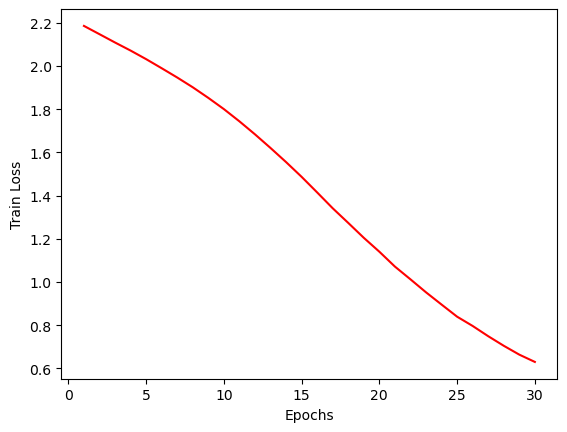

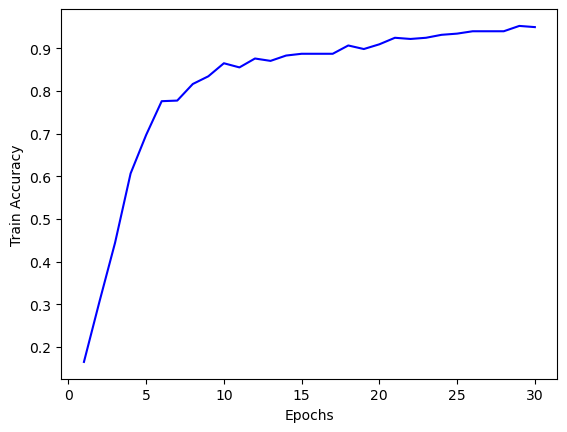

In [6]:
criterion= nn.CrossEntropyLoss()

learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)


losses=[]
accuracies=[]

model.train()

epochs = 30

for t in range(1,epochs+1):
    train_loss = 0.0
    train_accuracy = 0.0

    # 遍历 DataLoader
    for images, labels in train_loader:  
        # 1. 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 2. 反向传播 + 优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 累计 loss
        """特别的，loss是一个张量，其除了包含一个数字值外，还包含计算图中的一系列梯度信息，我们只需要其具体数值，故要用.item()提取出来"""
        train_loss += loss.item()  

        # 计算精度
        """
        特别的，torch.max()相比于numpy.max()会多返回一个值，第一个值是dim维度上的最大值，第二个值为dim维度上的最大值对应的下标
        此处我们只需要最大值对应的下标作为预测的类型，对于不需要的值我们一般用'_'来接收
        同样的，predicted和labels也是张量，(predicted==labels).sum()也是一个张量，我们还是需要用.item()来提取出具体的数值
        """
        _, predicted = torch.max(outputs, dim=1)
        train_accuracy += (predicted == labels).sum().item()

    train_mean_loss = train_loss / len(train_loader)
    train_mean_accuracy = train_accuracy / len(train_dataset)

    losses.append(train_mean_loss)
    accuracies.append(train_mean_accuracy)

    print(f" Epoch:{t}, loss: {train_mean_loss:>8f},  Accuracy: {(100*train_mean_accuracy):>0.1f}%")


plt.figure()
plt.plot(np.arange(1,epochs+1),losses,label="Train Loss",color="red")
plt.xlabel("Epochs")
plt.ylabel("Train Loss")
plt.show()

plt.figure()
plt.plot(np.arange(1,epochs+1),accuracies,label="Train Accuracy",color="blue")
plt.xlabel("Epochs")
plt.ylabel("Train Accuracy")
plt.show()
    
torch.save(model,"resnet_classification.pth")

由于原数据集中训练集的样本数较少，所以我们的batch_size取的也较小，导致出现了一定的震荡，不过从损失和精度变化曲线来看，迁移学习下模型的表现较为良好

## 测试CNN在测试数据集上的Performance

虽然变量名里写的是validation，但是实际上是当成test来用的

In [7]:
model = torch.load("resnet_classification.pth", weights_only=False)

model.eval()  #切换为评估模式

validation_accuracy = 0.0
validation_loss = 0.0 

with torch.no_grad():
    for images, labels in validation_loader:  
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        validation_loss += loss.item()
        
        # 计算精度
        _, predicted = torch.max(outputs, dim=1)
        validation_accuracy += (predicted == labels).sum().item()


validation_accuracy = 100 * validation_accuracy / len(validation_dataset)
validation_loss=validation_loss/len(validation_loader)

print(f"Validation Accuracy: {validation_accuracy:>0.1f}%, Validation Loss: {validation_loss:>8f} \n")

Validation Accuracy: 86.7%, Validation Loss: 0.805299 



可以看到，模型有一定的方差，但是并不是很大，和接下来的手写模型就能看出明显的差异了

### 要求2： 对比与3层卷积CNN网络的分类性能差异。

下面我们来手写一个3层的CNN

In [8]:
import torch
import torch.nn as nn

# 手写 3 层 CNN + 2层全连接（9分类）
class My3LayerCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 第 1 层卷积
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        
        # 第 2 层卷积
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # 第 3 层卷积
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # 全连接层
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 9)

    def forward(self, x):
        # 卷积块 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)  # 64→32
        
        # 卷积块 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)  # 32→16
        
        # 卷积块 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)  # 16→8
        
        # 分类
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# 创建模型
model = My3LayerCNN()

 Epoch:1, loss: 1.839476,  Accuracy: 38.3%
 Epoch:2, loss: 1.268509,  Accuracy: 60.6%
 Epoch:3, loss: 0.942307,  Accuracy: 77.2%
 Epoch:4, loss: 0.844220,  Accuracy: 73.6%
 Epoch:5, loss: 0.696458,  Accuracy: 79.9%
 Epoch:6, loss: 0.574777,  Accuracy: 85.4%
 Epoch:7, loss: 0.567304,  Accuracy: 83.1%
 Epoch:8, loss: 0.478995,  Accuracy: 86.5%
 Epoch:9, loss: 0.479873,  Accuracy: 86.1%
 Epoch:10, loss: 0.378150,  Accuracy: 89.6%
 Epoch:11, loss: 0.343098,  Accuracy: 91.0%
 Epoch:12, loss: 0.295090,  Accuracy: 94.2%
 Epoch:13, loss: 0.337186,  Accuracy: 91.7%
 Epoch:14, loss: 0.276156,  Accuracy: 94.4%
 Epoch:15, loss: 0.223234,  Accuracy: 96.5%
 Epoch:16, loss: 0.236621,  Accuracy: 94.3%
 Epoch:17, loss: 0.235637,  Accuracy: 93.6%
 Epoch:18, loss: 0.175580,  Accuracy: 98.1%
 Epoch:19, loss: 0.158820,  Accuracy: 97.2%
 Epoch:20, loss: 0.158495,  Accuracy: 97.5%
 Epoch:21, loss: 0.151810,  Accuracy: 97.5%
 Epoch:22, loss: 0.144584,  Accuracy: 97.1%
 Epoch:23, loss: 0.129731,  Accuracy: 98.

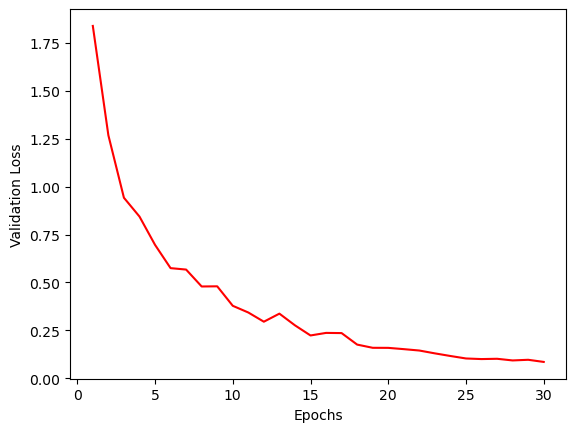

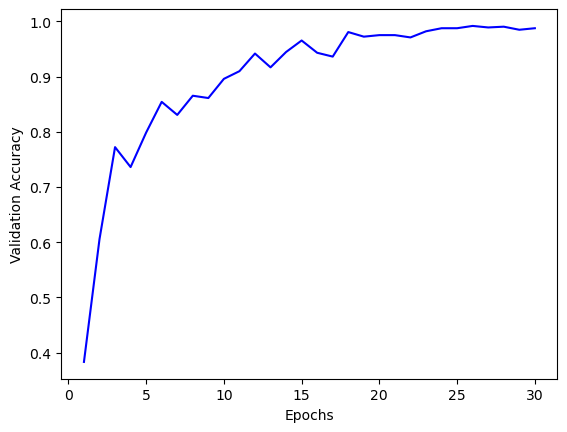

In [9]:
criterion= nn.CrossEntropyLoss()

learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# 记录训练集指标
losses=[]
accuracies=[]

# 记录测试集指标
test_losses = []
test_accuracies = []

model.train()

epochs = 30

for t in range(1,epochs+1):
    train_loss = 0.0
    correct = 0
    total = 0

    # 遍历训练集 DataLoader
    for images, labels in train_loader:  
        # 1. 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 2. 反向传播 + 优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 累计 loss
        train_loss += loss.item()

        # 计算精度
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_mean_loss = train_loss / len(train_loader)
    train_acc = correct / total

    losses.append(train_mean_loss)
    accuracies.append(train_acc)

    print(f" Epoch:{t}, loss: {train_mean_loss:>8f},  Accuracy: {(100*train_acc):>0.1f}%")


plt.figure()
plt.plot(np.arange(1,epochs+1),losses,label="Validation Loss",color="red")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.show()

plt.figure()
plt.plot(np.arange(1,epochs+1),accuracies,label="Validation Accuracy",color="blue")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.show()
    
torch.save(model,"my_classification.pth")

手写模型的网络层次比迁移学习的简单一些，在相同的一些超参数下震荡更加严重，且可以明显看出精度的上升速度极快，最终精度极高，且模型最终损失极小  
这初步说明模型将训练集里很多噪声给学进去了，正常的模型精度上升速度不会特别快，最终精度也不会特别高，最终损失也不会特别小

In [10]:
model = torch.load("my_classification.pth", weights_only=False)

model.eval()  #切换为评估模式

validation_accuracy = 0
validation_loss = 0.0 

with torch.no_grad():
    for images, labels in validation_loader:  
        outputs = model(images)
        
        loss = criterion(outputs, labels)
        validation_loss += loss.item()
        
        # 计算精度
        _, predicted = torch.max(outputs, 1)
        validation_accuracy += (predicted == labels).sum().item()

# 4. 计算平均 loss 和准确率
validation_loss = validation_loss / len(validation_loader)
validation_accuracy = 100 * validation_accuracy / len(validation_dataset)

# 5. 正确打印
print(f"Validation Accuracy: {validation_accuracy:>0.1f}%, Validation Avg loss: {validation_loss:>8f} \n")

Validation Accuracy: 60.6%, Validation Avg loss: 1.151321 



可以看到，模型最终的精度只有60%左右，而训练集最终精度为99%左右，发生了严重的过拟合

详细剖析为什么迁移学习可以有效预防过拟合问题：  
ResNet早已用于在其他大数据集上训练过，Pytorch官方将有着不同数据集下训练好参数的ResNet高度封装好了，比如本实验所用到的  
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)就是在ImageNet 1000分类上训练好的  

由于ResNet提前在别的数据集上训练过，因此其神经网络已经学会了一些通用的特征，比如普通线条，简单色块、纹理、光影等，这样我们通过迁移学习搭建的网络就不是从零开始白手起家的学习了，而是在一定基础上根据需求去微调，正式因为有着之前的“记忆”，所以模型就不会错把一些噪声当成需要学习的特征，或者说受到噪声的影响被削弱了  
打个比方，让一个有过素描或者油画经验的人去做园林设计，肯定要比一个纯白板的人做出来的效果好，因为先前的美术经验让他知道画面的构图、透视、色调大体该怎么配置，虽然园林设计领域的一些知识可能和素描油画的有一定出入，但是差距肯定不会很大，相反一个萌新小白可能就会很吃力

### 要求3： 将数据读取部分，修改为使用Datasets和Dataloader。

见文件代码块起始部分